---
title: Access SOCRATES Aircraft Data via GDEX Exchange
author: Chia-Wei Hsu
date: "2026-05-28"
---

# Access SOCRATES Aircraft Campaign Data via GDEX Exchange

## Required Packages

Please ensure the following packages are installed before proceeding.

| Category                        | Package      | Purpose |
|---                              |---           |---|
| **Data Access & Analysis**      | `fsspec`     | Open remote NetCDF files as a binary stream over HTTPS |
|                                 | `xarray`     | Load and manipulate NetCDF datasets |
|                                 | `pandas`     | Datetime conversion utilities |
|                                 | `numpy`      | Numerical operations and NaN masking |
| **Visualization (static)**      | `matplotlib` | Static scatter plot of the flight track |
| **Visualization (interactive)** | `folium`     | Interactive Leaflet map |

## Step 1 - Access the Data

The SOCRATES dataset is hosted on the [NCAR GDEX Exchange portal](https://data.gdex.ucar.edu/exchange/RAF-Socrates-2018/). The file is a standard NetCDF served over plain HTTPS. Because `xarray` cannot pass an HTTPS URL directly to its file-reading backends, we use `fsspec` to open the remote file as a binary stream and hand that stream to `xarray.open_dataset`.

:::{note} Why not pass the URL directly?
`xarray`'s `scipy` and `netcdf4` backends expect a local file path or a file-like object. `fsspec` handles the HTTP layer and returns a file-like object, bridging the gap between a remote URL and a local-style reader.
:::

In [ ]:
import fsspec
import xarray as xr

# the netcdf file is available to download at this URL, but xarray cannot read it directly.
# So we use fsspec to open the file as a binary stream through https, and then pass that stream to xarray. 
# This works because the xarray can read from file-like objects created by the fsspec library.
url = "https://data.gdex.ucar.edu/exchange/RAF-Socrates-2018/FF01.20180108.161000_002845.PNI.nc"
f = fsspec.open(url, mode="rb").open()
ds = xr.open_dataset(f)

## Step 2 - Plot the Flight Track (Static)

Plot the aircraft latitude (`GGLAT`) and longitude (`GGLON`) as a scatter plot with a connecting line ordered by time. Points are colored using the viridis colormap from earliest (purple) to latest (yellow). Start and end positions are highlighted with distinct markers.

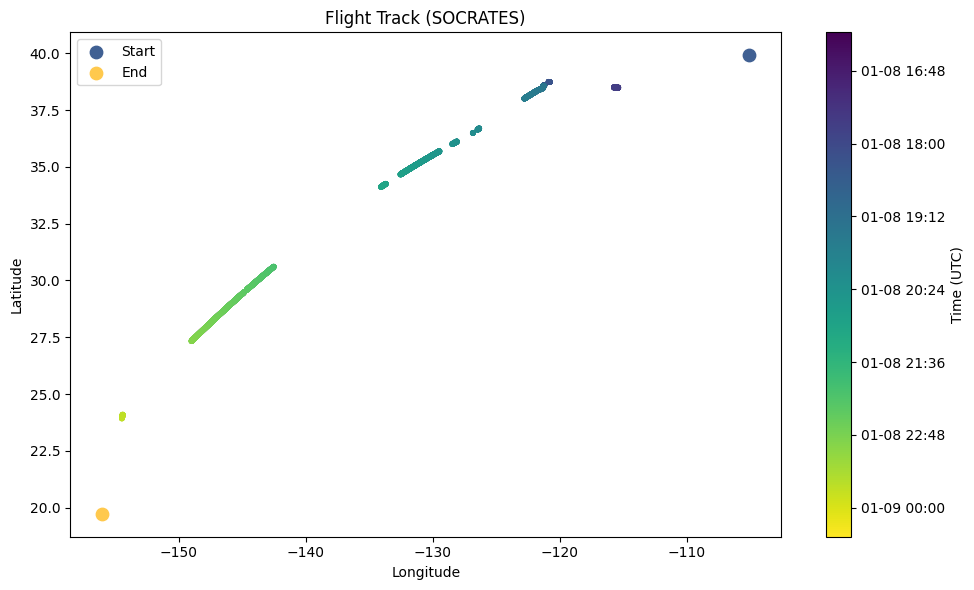

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

lon = ds.GGLON.values
lat = ds.GGLAT.values
time = ds.Time.values.astype('datetime64[ms]').astype('O')  # convert to Python datetimes
time_num = mdates.date2num(time)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(lon, lat, color='gray', linewidth=0.8, zorder=1)

sc = ax.scatter(lon, lat, c=time_num, cmap='viridis', s=10, zorder=2)

ax.scatter(lon[0], lat[0], color='#406093', s=80, zorder=3, label='Start')
ax.scatter(lon[-1], lat[-1], color='#FFC94D', s=80, zorder=3, label='End')

cbar = plt.colorbar(sc, ax=ax)
cbar.ax.invert_yaxis()
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
cbar.set_label('Time (UTC)')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Flight Track (SOCRATES)')
ax.legend()
plt.tight_layout()
plt.show()

## Step 3 - Interactive Map with Folium

Render the same flight track on an interactive Leaflet map using `folium`. NaN positions are removed before plotting. Points are subsampled every 30 seconds for performance; clicking any dot shows its exact UTC timestamp. The map is saved as a standalone HTML file that can be opened in any browser.

In [22]:
import folium
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd

lon = ds.GGLON.values
lat = ds.GGLAT.values
time = pd.to_datetime(ds.Time.values)

# Remove indices where either lon or lat is NaN
valid = ~(np.isnan(lon) | np.isnan(lat))
lon, lat, time = lon[valid], lat[valid], time[valid]

# Normalize time to [0,1] for colormap
t_norm = (time - time[0]) / (time[-1] - time[0])
cmap = plt.get_cmap('viridis')

def to_hex(val):
    return mcolors.to_hex(cmap(val))

# Subsample to keep map responsive (every 30s)
step = 30
lats = lat[::step]
lons = lon[::step]
t_vals = t_norm[::step]
times = time[::step]

# Center map on mean position
m = folium.Map(location=[lat.mean(), lon.mean()], zoom_start=5, tiles='CartoDB positron')

# Flight track line
coords = list(zip(lat.tolist(), lon.tolist()))
folium.PolyLine(coords, color='gray', weight=1.5, opacity=0.6).add_to(m)

# Colored circle markers
for la, lo, tv, t in zip(lats, lons, t_vals, times):
    folium.CircleMarker(
        location=[la, lo],
        radius=4,
        color=to_hex(float(tv)),
        fill=True,
        fill_color=to_hex(float(tv)),
        fill_opacity=0.85,
        popup=t.strftime('%Y-%m-%d %H:%M:%S UTC'),
    ).add_to(m)

# Start and end markers
folium.Marker([lat[0], lon[0]], tooltip='Start: ' + time[0].strftime('%H:%M UTC'),
              icon=folium.Icon(color='blue', icon='play')).add_to(m)
folium.Marker([lat[-1], lon[-1]], tooltip='End: ' + time[-1].strftime('%H:%M UTC'),
              icon=folium.Icon(color='orange', icon='stop')).add_to(m)

m.save('flight_track.html')
print('Saved to flight_track.html')

Saved to flight_track.html


In [23]:
m